# Volume change on shelf over time, ACCESS-OM2-01

This notebook is incomplete, because I haven't run the daily data for ACCESS-OM2-01 yet.

In [1]:
import glob
import dask.distributed as dsk
import matplotlib.pyplot as plt
import xarray as xr
import cf_xarray as cfxr
import numpy as np
import xesmf as xe
from matplotlib.colors import to_rgba

import cmocean as cm
import cartopy.crs as ccrs

import cartopy.feature as cft
import matplotlib.path as mpath

import warnings # ignore these warnings
warnings.filterwarnings("ignore", category = FutureWarning)
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = RuntimeWarning)

In [2]:
lat_slice = slice(-79,-59)

# Importing data
paths_C = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/01deg_jra55v13_ryf9091_21mbath_daily-fc7aefa1/output000/ocean/ocean_daily.nc'))
paths_M = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/access-ssp126-sofia_daily-expt-3deaf0e1/output000/ocean/ocean_daily.nc'))

In [3]:
paths_M

array(['/scratch/x77/kc5856/access-om2/archive/access-ssp126-sofia_daily-expt-3deaf0e1/output000/ocean/ocean_daily.nc'],
      dtype='<U109')

In [4]:
# Time variant variables
def preprocess(ds):
    ds = ds[['dzt','salt_tendency']].sel(yt_ocean=lat_slice)
    return ds

data_C = xr.open_mfdataset(paths_C, preprocess = preprocess, chunks = 'auto')
data_M = xr.open_mfdataset(paths_M, preprocess = preprocess, chunks = 'auto')

In [5]:
# Shelf mask

def shelf_mask_isobath(var, model_dict):

    paths = {
             "mom5": "/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz",
             "mom6_01": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_01deg.nc",
            "mom6_005": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_005deg.nc"
             }

    var = var.cf.sel({'latitude': slice(-90, -59)})

    if paths[model_dict][-3:] == '.nc':
        shelf_mask = xr.open_dataset(paths[model_dict])['contour_masked_above']
    else:
        contour_file = np.load(paths[model_dict])
        shelf_mask = xr.DataArray(contour_file['contour_masked_above'],
                                  coords = var.coords, 
                                  dims = var.dims,
                                  name = 'contour_masked_above')
    
    shelf_mask = xr.where(shelf_mask == 0, 1, 0)
    masked_var = var * shelf_mask
    
    return masked_var, shelf_mask

In [6]:
depth = xr.open_dataset('/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output012/ocean/ocean_grid.nc')['ht']
land_mask = (0 * depth).fillna(1)
land = xr.where(np.isnan(depth.rename('land_1')), 1, np.nan)
depth_shelf, shelf_mask = shelf_mask_isobath(depth, 'mom5')

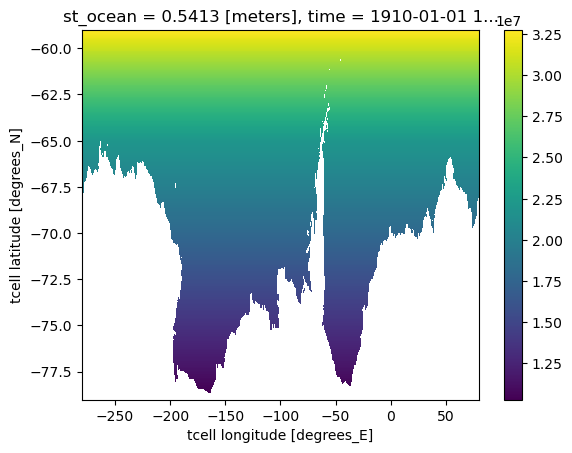

In [7]:
# Doing spatial average
area = xr.open_dataset('/scratch/x77/kc5856/access-om2/archive/01deg_jra55v13_ryf9091_21mbath_daily-fc7aefa1/output000/ocean/ocean_grid.nc')['area_t']
var = data_C.salt_tendency.isel(time=0).isel(st_ocean=0)
area_corr = area*(var*0 +1)
area_corr.plot()

In [26]:
# Salinity variable
vol_C_time = (area_corr * data_C.dzt).where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])
vol_M_time = (area_corr * data_M.dzt).where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])

In [27]:
vol_C_time

<xarray.DataArray (time: 3, st_ocean: 75)> Size: 900B
dask.array<sum-aggregate, shape=(3, 75), dtype=float32, chunksize=(2, 38), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) object 24B 1910-01-01 12:00:00 ... 1910-01-03 12:00:00
  * st_ocean  (st_ocean) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03

In [28]:
vol_C_time = vol_C_time.load()
vol_M_time = vol_M_time.load()

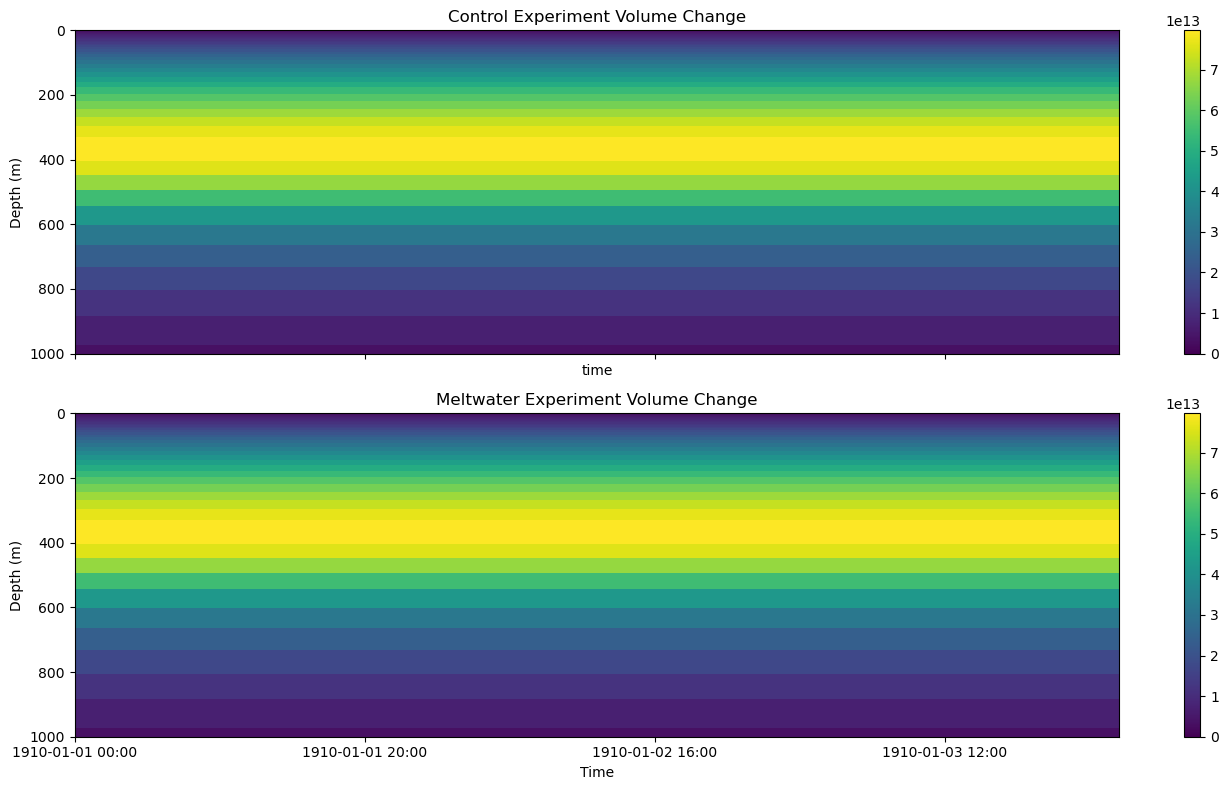

In [29]:
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Control experiment
vol_C_time.plot(ax=axs[0], y='st_ocean', cmap='viridis')
axs[0].set_ylabel('Depth (m)')
axs[0].set_ylim(0,1000)
axs[0].invert_yaxis()
axs[0].set_title('Control Experiment Volume Change')

# Meltwater experiment
vol_M_time.plot(ax=axs[1], y='st_ocean', cmap='viridis')
axs[1].set_ylabel('Depth (m)')
axs[1].set_ylim(0,1000)
axs[1].invert_yaxis()
axs[1].set_title('Meltwater Experiment Volume Change')

axs[1].set_xlabel('Time')

plt.tight_layout()
plt.show()

In [30]:
# Anomaly
vol_anom_time = vol_M_time - vol_C_time
vol_anom_time = vol_anom_time.load()

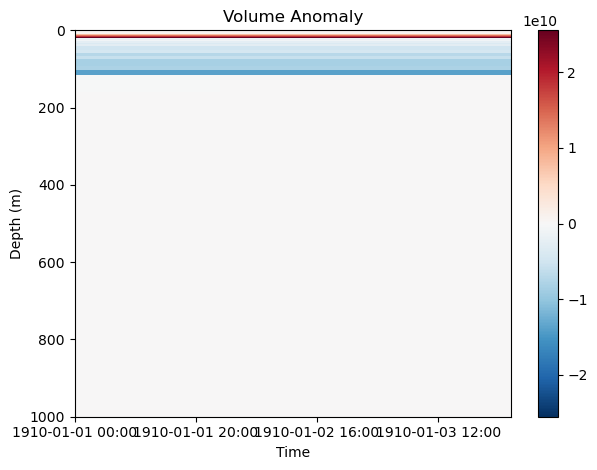

In [31]:
vol_anom_time.plot(y='st_ocean', cmap='RdBu_r')
plt.ylabel('Depth (m)')
plt.ylim(0,1000)
plt.title('Volume Anomaly')
plt.gca().invert_yaxis()
plt.xlabel('Time')
plt.tight_layout()
plt.show()

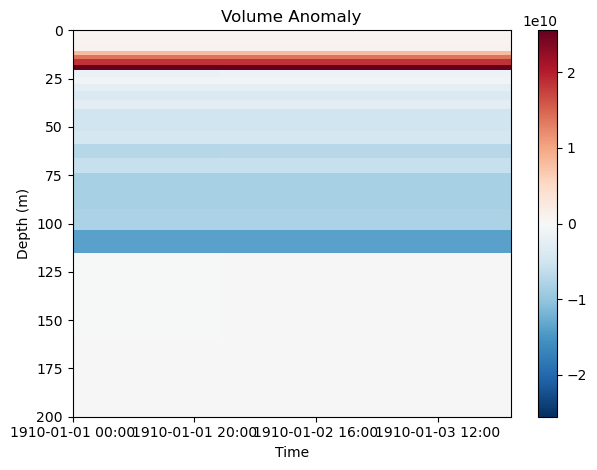

In [32]:
vol_anom_time.plot(y='st_ocean', cmap='RdBu_r')
plt.ylabel('Depth (m)')
plt.ylim(0,200)
plt.title('Volume Anomaly')
plt.gca().invert_yaxis()
plt.xlabel('Time')
plt.tight_layout()
plt.show()

In [34]:
vol_anom_time

<xarray.DataArray (time: 3, st_ocean: 75)> Size: 900B
array([[ 4.8470426e+08,  5.3529805e+08,  5.9165901e+08,  6.5404928e+08,
         7.2246886e+08,  7.9901491e+08,  8.8185242e+08,  8.0929096e+09,
         1.3812892e+10,  1.8481152e+10,  2.5516048e+10, -1.6085156e+09,
        -9.3428122e+08, -2.4578621e+09, -3.7213962e+09, -2.6717716e+09,
        -5.0310676e+09, -5.1264881e+09, -4.5508198e+09, -7.2037171e+09,
        -5.8615398e+09, -8.4724941e+09, -8.5815460e+09, -8.1054925e+09,
        -1.3916701e+10, -4.1943040e+06, -4.1943040e+06, -8.3886080e+06,
         4.1943040e+06,  4.1943040e+06,  4.1943040e+06,  4.1943040e+06,
         1.6777216e+07,  2.5165824e+07,  2.5165824e+07,  4.1943040e+07,
         3.3554432e+07,  3.3554432e+07,  2.9360128e+07,  2.9360128e+07,
         1.6777216e+07,  1.4680064e+07,  1.2582912e+07,  7.3400320e+06,
         2.0971520e+06,  1.5728640e+06,  5.2428800e+05,  2.6214400e+05,
         2.6214400e+05,  1.3107200e+05,  0.0000000e+00,  6.5536000e+04,
         3.2768000e+04,  0.0000000e+00,  1.6384000e+04,  8.1920000e+03,
         5.1200000e+02,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 4.8732570e+08,  5.3870592e+08,  5.9585331e+08,  6.5745715e+08,
...
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 4.8680141e+08,  5.3844378e+08,  5.9454259e+08,  6.5719501e+08,
         7.2613888e+08,  8.0320922e+08,  8.8709530e+08,  8.1165025e+09,
         1.3847495e+10,  1.8522571e+10,  2.5566904e+10, -1.5833498e+09,
        -9.0806682e+08, -2.4316477e+09, -3.6930847e+09, -2.6424115e+09,
        -4.9996104e+09, -5.0950308e+09, -4.5172654e+09, -7.1680655e+09,
        -5.8258883e+09, -8.4347453e+09, -8.5458944e+09, -8.0677437e+09,
        -1.3881049e+10,  3.7748736e+07,  4.1943040e+07,  4.6137344e+07,
         5.4525952e+07,  5.4525952e+07,  7.5497472e+07,  8.8080384e+07,
         1.0066330e+08,  1.0066330e+08,  1.0905190e+08,  1.3421773e+08,
         1.2582912e+08,  1.1744051e+08,  9.6468992e+07,  7.9691776e+07,
         5.0331648e+07,  3.9845888e+07,  2.5165824e+07,  2.2020096e+07,
         1.1534336e+07,  6.2914560e+06,  3.1457280e+06,  1.7039360e+06,
         7.8643200e+05,  5.8982400e+05,  3.9321600e+05,  3.2768000e+05,
         1.6384000e+05,  1.3107200e+05,  7.3728000e+04,  2.0480000e+04,
         1.0240000e+03,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00]], dtype=float32)
Coordinates:
  * time      (time) object 24B 1910-01-01 12:00:00 ... 1910-01-03 12:00:00
  * st_ocean  (st_ocean) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03

Okay so we see that volume is changing, mostly around 300m depth. Is there a better way to present this information? This plot is a bit rough.

In [35]:
vol_C_column = vol_C_time.sum('st_ocean')
vol_M_column = vol_M_time.sum('st_ocean')

I don't think I need to thickness-weight this because volcello should already account for that?

In [36]:
vol_C_column = vol_C_column.load()
vol_M_column = vol_M_column.load()

In [37]:
vol_anom_column = vol_M_column - vol_C_column

In [38]:
vol_M_column

<xarray.DataArray (time: 3)> Size: 12B
array([1.3952773e+15, 1.3952923e+15, 1.3953017e+15], dtype=float32)
Coordinates:
  * time     (time) object 24B 1910-01-01 12:00:00 ... 1910-01-03 12:00:00

In [39]:
vol_C_column

<xarray.DataArray (time: 3)> Size: 12B
array([1.3952848e+15, 1.3952980e+15, 1.3953074e+15], dtype=float32)
Coordinates:
  * time     (time) object 24B 1910-01-01 12:00:00 ... 1910-01-03 12:00:00

In [40]:
vol_anom_column

<xarray.DataArray (time: 3)> Size: 12B
array([-7.5161928e+09, -5.6371446e+09, -5.6371446e+09], dtype=float32)
Coordinates:
  * time     (time) object 24B 1910-01-01 12:00:00 ... 1910-01-03 12:00:00

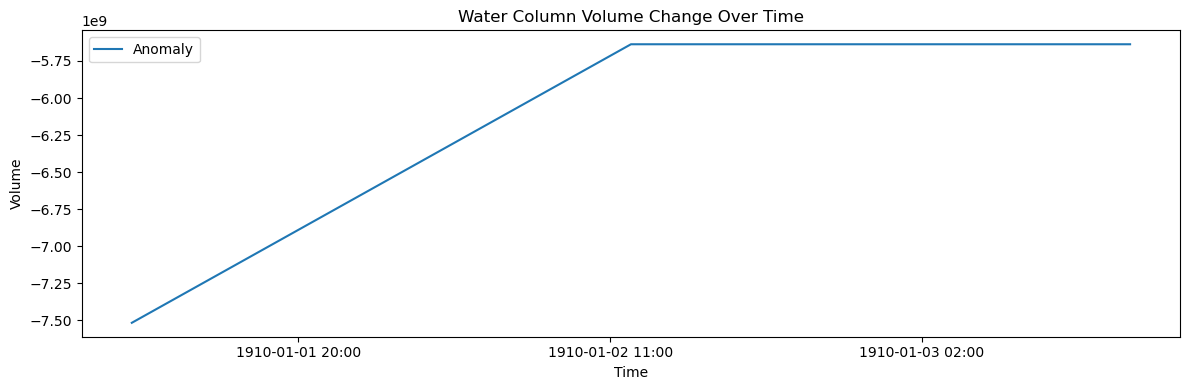

In [41]:
plt.figure(figsize=(12, 4))

# vol_C_column.plot(label='Control')
# vol_M_column.plot(label='Meltwater')
vol_anom_column.plot(label='Anomaly')

plt.legend()
plt.ylabel('Volume')
plt.xlabel('Time')
plt.title('Water Column Volume Change Over Time')
plt.tight_layout()
plt.show()

In [42]:
vol_anom_column_pan = xr.open_dataarray('/g/data/x77/kc5856/analysis/access-panan-comparison/vol_anom_column_pan01.nc')

In [44]:
vol_anom_column_acc_new = vol_anom_column.to_series()
vol_anom_column_acc_new = vol_anom_column_acc_new['1910-01-01':'1919-12-16']
vol_anom_column_pan_new = vol_anom_column_pan.to_series()
vol_anom_column_pan_new = vol_anom_column_pan_new['2001-01-01':'2010-10-16']

In [45]:
# Reset index to normalized months
vol_anom_column_pan_new.index = range(1, len(vol_anom_column_pan_new)+1)
vol_anom_column_acc_new.index = range(1, len(vol_anom_column_acc_new)+1)

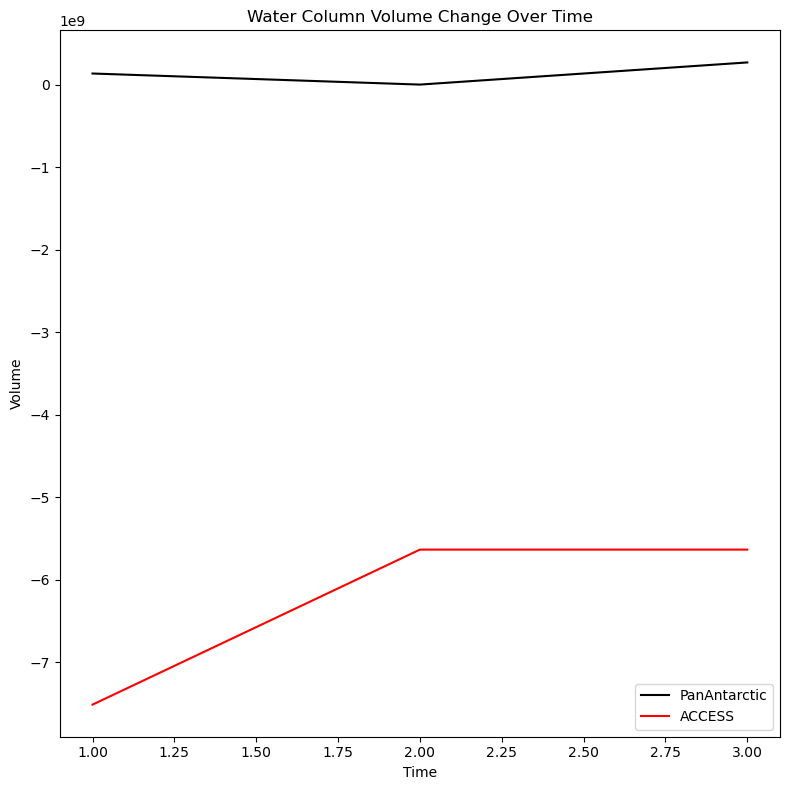

In [46]:
plt.figure(figsize=(8, 8))

plt.plot(vol_anom_column_pan_new.index, vol_anom_column_pan_new.values, label="PanAntarctic", color='black')
plt.plot(vol_anom_column_acc_new.index, vol_anom_column_acc_new.values, label="ACCESS", color='red')

plt.legend()
plt.ylabel('Volume')
plt.xlabel('Time')
plt.title('Water Column Volume Change Over Time')
plt.tight_layout()
plt.show()